# Synthesis - matching the model to the mechanism

Across the three case studies one theme recurs: **the right model is the one whose structure mirrors how the disease actually spreads.** A plain SIR can be *fitted* to almost any epidemic curve, but it cannot answer the questions that matter - which intervention will work, and why. This notebook pulls the three studies together and tests that claim directly.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "simulation").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulation import compartmental as cm
from simulation import plotting, metrics
from simulation.grid import ABMParams, InterventionSettings, run_ensemble
from simulation.agents import State

plotting.use_house_style()

## Three tempos

The same susceptible-infectious-removed process, run with mechanism-appropriate structure, produces very different epidemic shapes: a sharp reservoir-driven cholera wave, a fast airborne COVID wave, and a slow Ebola epidemic paced by its long incubation.

In [2]:
# Re-run the chosen model for each case study so this notebook stands alone.
# --- waterborne: cholera SIRB (national-aggregate R0 = 1.7, fitted to PAHO) ---
N_ch = 330_000
beta_ch = 1.70 * (0.05 * N_ch) * 0.20 * 0.50 / (0.00625 * N_ch)
chol = cm.SIRB(cm.SIRBParams(beta_ch, 0.20, 0.00625, 0.50, 0.05 * N_ch), N_ch)
chol_out = chol.simulate([N_ch - 20, 20, 0, 18], 365, 366)

# --- airborne: COVID SIRD ---
N_co = 1_000_000
g_co = 1 / 6.0; mu_co = 0.007 * g_co / 0.993
covid = cm.SIRD(cm.SIRDParams(2.5 * (g_co + mu_co), g_co, mu_co), N_co)
covid_out = covid.simulate([N_co - 100, 100, 0, 0], 220, 221)

# --- direct contact: Ebola SEAIQR (R0 = 1.6, fitted to WHO cumulative data) ---
N_eb = 38_000
g_eb = 1 / 7.0
beta_eb = 1.6 * g_eb / (0.3 * 0.3 + 0.7)
ebola = cm.SEAIQR(cm.SEAIQRParams(beta_eb, 1 / 11.0, g_eb, rho=0.7, eta=0.3, q=0.0), N_eb)
ebola_out = ebola.simulate([N_eb - 5, 0, 0, 5, 0, 0], 500, 501)
print("re-simulated all three case studies")

re-simulated all three case studies


cholera  peak infectious fraction = 0.070 on day 58
covid    peak infectious fraction = 0.233 on day 38
ebola    peak infectious fraction = 0.022 on day 257


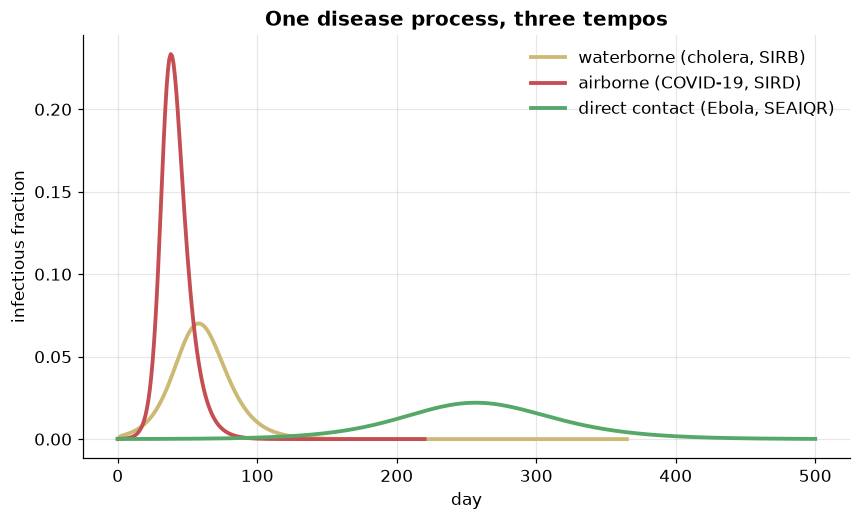

In [3]:
# Same axis, infectious as a fraction of each population: three very different tempos.
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(chol_out.index, chol_out["I"] / N_ch, color=plotting.PALETTE["B"], lw=2.5,
        label="waterborne (cholera, SIRB)")
ax.plot(covid_out.index, covid_out["I"] / N_co, color=plotting.PALETTE["I"], lw=2.5,
        label="airborne (COVID-19, SIRD)")
ax.plot(ebola_out.index, ebola_out["I"] / N_eb, color=plotting.PALETTE["R"], lw=2.5,
        label="direct contact (Ebola, SEAIQR)")
ax.set_xlabel("day"); ax.set_ylabel("infectious fraction")
ax.set_title("One disease process, three tempos")
ax.legend()
for name, df, N in [("cholera", chol_out, N_ch), ("covid", covid_out, N_co), ("ebola", ebola_out, N_eb)]:
    pk, t = metrics.peak(df["I"], df.index)
    print(f"{name:8s} peak infectious fraction = {pk / N:.3f} on day {t:.0f}")

## Which model, and why

Each transmission mode selects its own model structure and its own effective intervention.

In [4]:
selection = pd.DataFrame([
    {"transmission": "waterborne", "case study": "cholera, Peru 1991",
     "chosen model": "SIRB", "R0": round(chol.r0(), 2),
     "what sets the pace": "reservoir build-up (shed -> decay)",
     "key intervention": "sanitation / water treatment (WASH)"},
    {"transmission": "airborne", "case study": "COVID-19 first wave",
     "chosen model": "SIRD / SEAIQR", "R0": round(covid.r0(), 2),
     "what sets the pace": "short generation, latent + asymptomatic",
     "key intervention": "vaccination + sustained distancing"},
    {"transmission": "direct contact", "case study": "Ebola, W. Africa 2014",
     "chosen model": "SEAIQR", "R0": round(ebola.r0(), 2),
     "what sets the pace": "long (~11 day) incubation period",
     "key intervention": "rapid case isolation / contact tracing"},
]).set_index("transmission")
selection

,case study,chosen model,R0,what sets the pace,key intervention
transmission,,,,,
waterborne,"cholera, Peru 1991",SIRB,1.7,reservoir build-up (shed -> decay),sanitation / water treatment (WASH)
airborne,COVID-19 first wave,SIRD / SEAIQR,2.5,"short generation, latent + asymptomatic",vaccination + sustained distancing
direct contact,"Ebola, W. Africa 2014",SEAIQR,1.6,long (~11 day) incubation period,rapid case isolation / contact tracing


## The same intervention is not equally effective everywhere

To make the model-selection argument concrete, we apply *one* intervention -
isolating 60% of detected cases - across all three agent-based mechanisms and
measure the reduction in attack rate. The result tracks the biology: isolation
works when transmission depends on the infectious person moving or making
contact, and barely helps when a stationary source can still infect at a
distance.

waterborne      attack 0.73 -> 0.33  (55% reduction)


airborne        attack 0.95 -> 0.86  (9% reduction)


direct contact  attack 0.64 -> 0.37  (43% reduction)


Text(0.5, 1.0, 'Effect of isolating 60% of cases, by transmission mechanism')

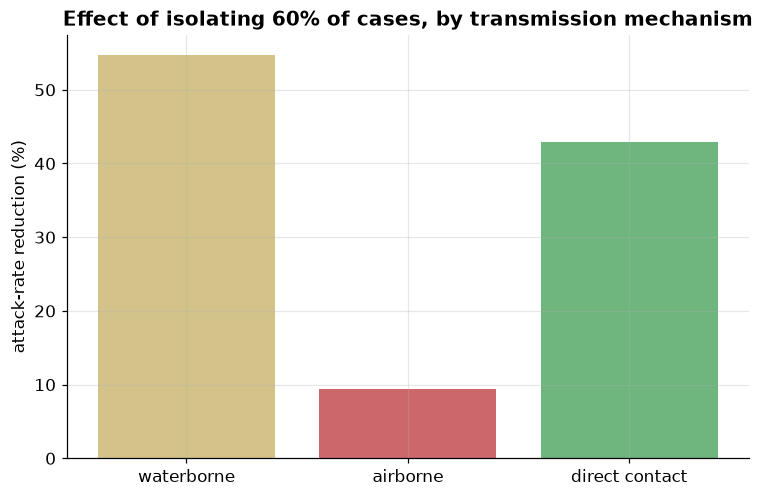

In [5]:
setups = {
    "waterborne": dict(grid_size=80, n_agents=2500, mechanism="waterborne",
        params=ABMParams(infect_prob=0.9, shed_rate=3.0, decay=0.2, kappa=2.0,
                         recovery_prob=0.06, step_prob=0.85), n_infected=10, base_seed=100),
    "airborne": dict(grid_size=80, n_agents=2500, mechanism="airborne",
        params=ABMParams(infect_prob=0.18, radius=2.0, recovery_prob=0.12,
                         step_prob=0.85), n_infected=10, base_seed=100),
    "direct contact": dict(grid_size=50, n_agents=3000, mechanism="contact",
        params=ABMParams(infect_prob=0.25, recovery_prob=0.08, step_prob=0.8),
        n_infected=10, base_seed=50),
}
isolate = InterventionSettings(quarantine_fraction=0.6, quarantine_delay=2)

reductions = {}
for name, kw in setups.items():
    base, _ = run_ensemble(6, 80, **kw)
    iso, _ = run_ensemble(6, 80, interventions=isolate, **kw)
    nag = kw["n_agents"]
    a_base = 1 - base[-1, State.SUSCEPTIBLE] / nag
    a_iso = 1 - iso[-1, State.SUSCEPTIBLE] / nag
    reductions[name] = 100 * (a_base - a_iso) / a_base
    print(f"{name:15s} attack {a_base:.2f} -> {a_iso:.2f}  ({reductions[name]:.0f}% reduction)")

fig, ax = plt.subplots()
colours = [plotting.PALETTE["B"], plotting.PALETTE["I"], plotting.PALETTE["R"]]
ax.bar(list(reductions.keys()), list(reductions.values()), color=colours, alpha=0.85)
ax.set_ylabel("attack-rate reduction (%)")
ax.set_title("Effect of isolating 60% of cases, by transmission mechanism")

## Conclusion

The agent-based experiment makes the argument in one figure: isolating cases removes roughly half the attack rate for contact- and reservoir-mediated spread, but almost nothing for airborne spread, because an airborne source keeps transmitting from wherever it is isolated. That is why the case studies do not share a single model. Cholera needs the environmental reservoir (SIRB) so that water and sanitation have somewhere to act; COVID-19 needs death, vaccination and latent/asymptomatic structure (SIRD, SIRDV, SEAIQR) to compare lockdown, vaccines and quarantine; Ebola needs the exposed compartment (SEAIQR) to get its slow timing right and to show why isolation works. Choosing the model is itself part of the science. See `conclusions.md` for the full write-up.